In [1]:
import pandas as pd                                                                                                                                                                 
            
  


In [2]:
df = pd.read_csv("finsecure_transactions.csv") 

In [3]:
print(df.shape)   

(100000, 13)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   transaction_id              100000 non-null  object 
 1   user_id                     100000 non-null  object 
 2   transaction_amount          100000 non-null  float64
 3   merchant_category           100000 non-null  object 
 4   transaction_hour            100000 non-null  int64  
 5   day_of_week                 100000 non-null  int64  
 6   device_type                 100000 non-null  object 
 7   location_city               100000 non-null  object 
 8   distance_from_home          100000 non-null  float64
 9   is_new_device               100000 non-null  int64  
 10  failed_attempts_last_1hr    100000 non-null  int64  
 11  avg_transaction_amount_30d  100000 non-null  float64
 12  is_fraud                    100000 non-null  int64  
dtypes: float64(3), 

In [5]:
df.head()

,transaction_id,user_id,transaction_amount,merchant_category,transaction_hour,day_of_week,device_type,location_city,distance_from_home,is_new_device,failed_attempts_last_1hr,avg_transaction_amount_30d,is_fraud
0,TXN0000001,USR34321,6703.07,fuel,19,1,mobile,Jaipur,13.45,0,0,9279.82,0
1,TXN0000002,USR20031,35990.49,electronics,12,0,mobile,Kolkata,5.43,0,0,28091.42,0
2,TXN0000003,USR19862,17316.27,electronics,18,4,POS,Pune,11.02,0,0,14646.82,0
3,TXN0000004,USR30221,638.32,fuel,14,4,mobile,Chennai,26.97,0,1,396.88,0
4,TXN0000005,USR23407,6837.65,restaurant,15,3,web,Surat,10.02,0,0,5831.27,0


In [6]:
print(df["is_fraud"].value_counts())

is_fraud
0    98000
1     2000
Name: count, dtype: int64


In [7]:
df.isna().sum()

transaction_id                0
user_id                       0
transaction_amount            0
merchant_category             0
transaction_hour              0
day_of_week                   0
device_type                   0
location_city                 0
distance_from_home            0
is_new_device                 0
failed_attempts_last_1hr      0
avg_transaction_amount_30d    0
is_fraud                      0
dtype: int64

In [8]:
df.describe()

,transaction_amount,transaction_hour,day_of_week,distance_from_home,is_new_device,failed_attempts_last_1hr,avg_transaction_amount_30d,is_fraud
count,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,8874.980192,12.548080,3.00163,18.266367,0.092830,0.267890,8151.817547,0.020000
std,13665.969651,5.116877,2.00284,37.782780,0.290196,0.734786,10773.396410,0.140001
min,56.510000,0.000000,0.00000,0.000000,0.000000,0.000000,32.510000,0.000000
25%,2539.995000,9.000000,1.00000,4.380000,0.000000,0.000000,2381.887500,0.000000
50%,5033.770000,13.000000,3.00000,10.680000,0.000000,0.000000,4799.375000,0.000000
75%,10025.602500,16.000000,5.00000,21.620000,0.000000,0.000000,9638.615000,0.000000
max,200000.000000,23.000000,6.00000,1254.060000,1.000000,5.000000,208702.390000,1.000000


In [9]:
import matplotlib.pyplot as plt

In [12]:
legit = df[df["is_fraud"] == 0]["transaction_amount"]                                                                                                                               
fraud = df[df["is_fraud"] == 1]["transaction_amount"]



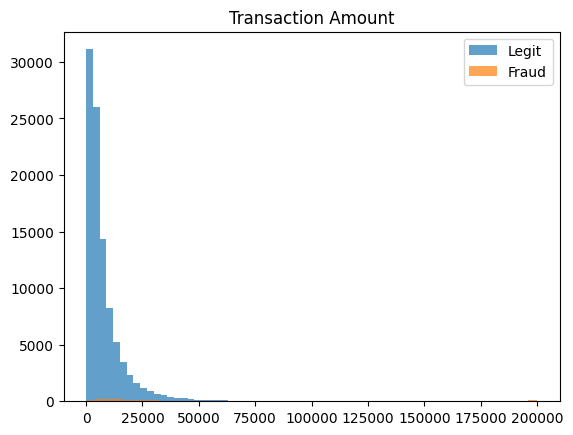

In [13]:

                                                                                                                                                                                      
plt.hist(legit, bins=50, alpha=0.7, label="Legit")                                                                                                                                  
plt.hist(fraud, bins=50, alpha=0.7, label="Fraud")
plt.title("Transaction Amount")                                                                                                                                                     
plt.legend()                   
plt.show()


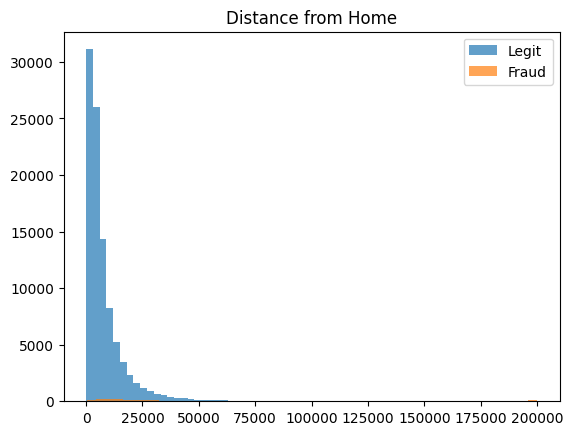

In [14]:
plt.hist(legit, bins=50, alpha=0.7, label="Legit")                                                                                                                                  
plt.hist(fraud, bins=50, alpha=0.7, label="Fraud")
plt.title("Distance from Home")                                                                                                                                                     
plt.legend()                                                                                                                                                                        
plt.show()

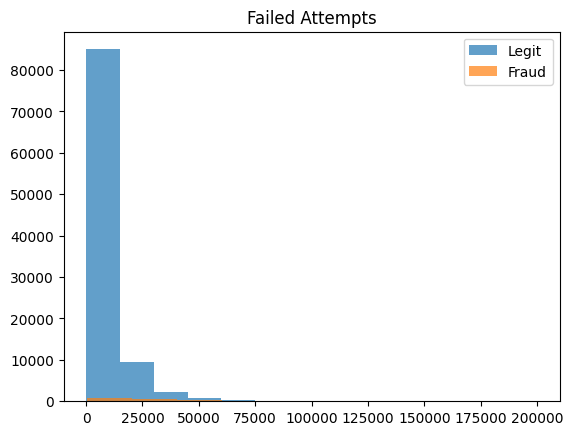

In [15]:
plt.hist(legit, bins=10, alpha=0.7, label="Legit")
plt.hist(fraud, bins=10, alpha=0.7, label="Fraud")                                                                                                                                  
plt.title("Failed Attempts")                      
plt.legend()                
plt.show()

In [16]:
print("Legit avg distance:", df[df["is_fraud"] == 0]["distance_from_home"].mean())
print("Fraud avg distance:", df[df["is_fraud"] == 1]["distance_from_home"].mean())

Legit avg distance: 15.02452326530612
Fraud avg distance: 177.11669


In [17]:
print("Legit avg failed attempts:", df[df["is_fraud"] == 0]["failed_attempts_last_1hr"].mean())                                                                                     
print("Fraud avg failed attempts:", df[df["is_fraud"] == 1]["failed_attempts_last_1hr"].mean())

Legit avg failed attempts: 0.23603061224489796
Fraud avg failed attempts: 1.829


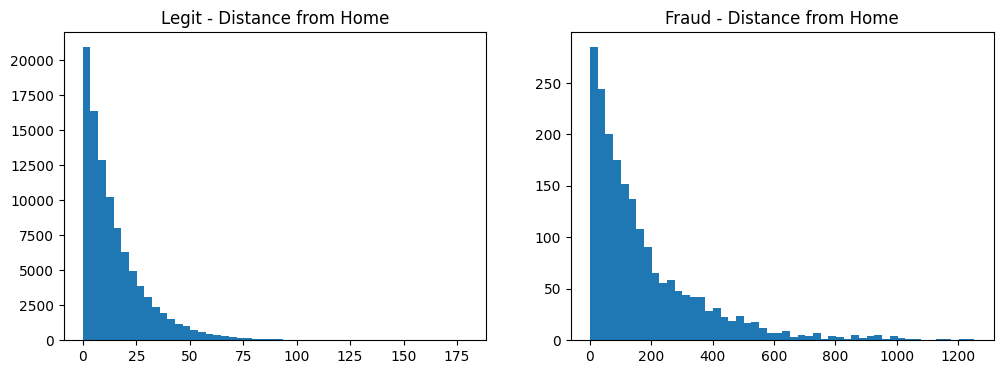

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))                                                                                                                                     
                                                                                                                                                                                      
axes[0].hist(df[df["is_fraud"] == 0]["distance_from_home"], bins=50)                                                                                                                
axes[0].set_title("Legit - Distance from Home")                                                                                                                                     
                                                                                                                                                                                    
axes[1].hist(df[df["is_fraud"] == 1]["distance_from_home"], bins=50)
axes[1].set_title("Fraud - Distance from Home")
                                                                                                                                                                                      
plt.show()

In [19]:
print(df.groupby("merchant_category")["is_fraud"].mean().sort_values(ascending=False))

merchant_category
jewelry          0.108275
electronics      0.049391
travel           0.038953
entertainment    0.031710
utilities        0.023541
clothing         0.017085
fuel             0.007854
pharmacy         0.007820
restaurant       0.004646
grocery          0.004440
Name: is_fraud, dtype: float64


In [20]:
print(df.groupby("device_type")["is_fraud"].mean().sort_values(ascending=False))

device_type
mobile    0.024038
web       0.020660
POS       0.003584
Name: is_fraud, dtype: float64


In [21]:
print(df.groupby("is_new_device")["is_fraud"].mean())

is_new_device
0    0.006338
1    0.153506
Name: is_fraud, dtype: float64


['mobile' 'POS' 'web']
['fuel' 'electronics' 'restaurant' 'grocery' 'clothing' 'jewelry'
 'pharmacy' 'travel' 'utilities' 'entertainment']
